In [61]:
import pandas as pd

In [62]:
import numpy as np

In [63]:
import matplotlib.pyplot as plt

In [64]:
import seaborn as sns

In [65]:
from sklearn.preprocessing import MinMaxScaler

In [66]:
%matplotlib inline

In [130]:
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression

In [131]:
from sklearn.ensemble import RandomForestRegressor

In [132]:
from sklearn.model_selection import train_test_split

In [147]:
from sklearn.decomposition import TruncatedSVD

In [67]:
df = pd.read_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/raw/vgchartz-2024.csv")

In [68]:
# 1.Data Cleaning & Handling Missing Values

In [69]:
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


In [70]:
df.dtypes # check data types

img              object
title            object
console          object
genre            object
publisher        object
developer        object
critic_score    float64
total_sales     float64
na_sales        float64
jp_sales        float64
pal_sales       float64
other_sales     float64
release_date     object
last_update      object
dtype: object

In [71]:
df = df.drop(['img','last_update'], axis=1) # remove columns

In [72]:
df.head()

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06


In [73]:
df = df.rename(columns={"title": "Game Title", "console": "Console",
                        "genre": "Genre", "publisher": "Publisher",
                        "developer": "Developer", "critic_score": "Critic Score",
                        "total_sales": "Sales", "na_sales": "North American Sales",
                        "jp_sales": "Japanese Sales", "pal_sales": "EU Sales", 
                        "other_sales": "Other Sales", "release_date": "Release Date",})  # rename columns

In [74]:
df.shape # check dimentions

(64016, 12)

In [75]:
df.count() # count rows

Game Title              64016
Console                 64016
Genre                   64016
Publisher               64016
Developer               63999
Critic Score             6678
Sales                   18922
North American Sales    12637
Japanese Sales           6726
EU Sales                12824
Other Sales             15128
Release Date            56965
dtype: int64

In [76]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)   #check duplicates 

number of duplicate rows:  (21, 12)


In [77]:
df = df.drop_duplicates() # drop duplicates

In [78]:
print(df.isnull().sum()) # missing values ( null )

Game Title                  0
Console                     0
Genre                       0
Publisher                   0
Developer                  17
Critic Score            57317
Sales                   45076
North American Sales    51358
Japanese Sales          57272
EU Sales                51171
Other Sales             48867
Release Date             7051
dtype: int64


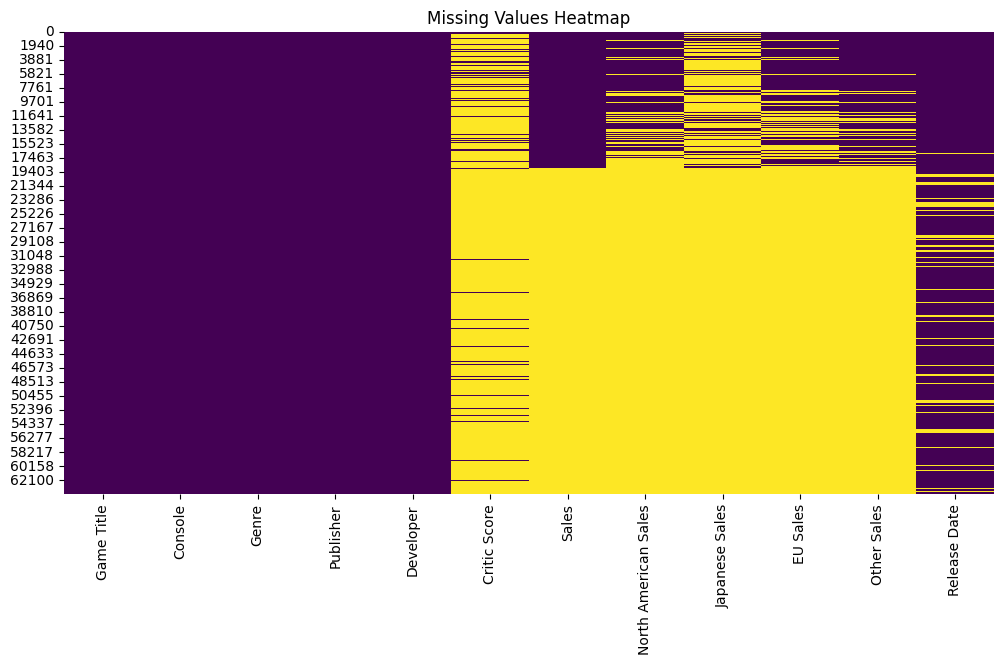

In [79]:
# Heatmap of missing values

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

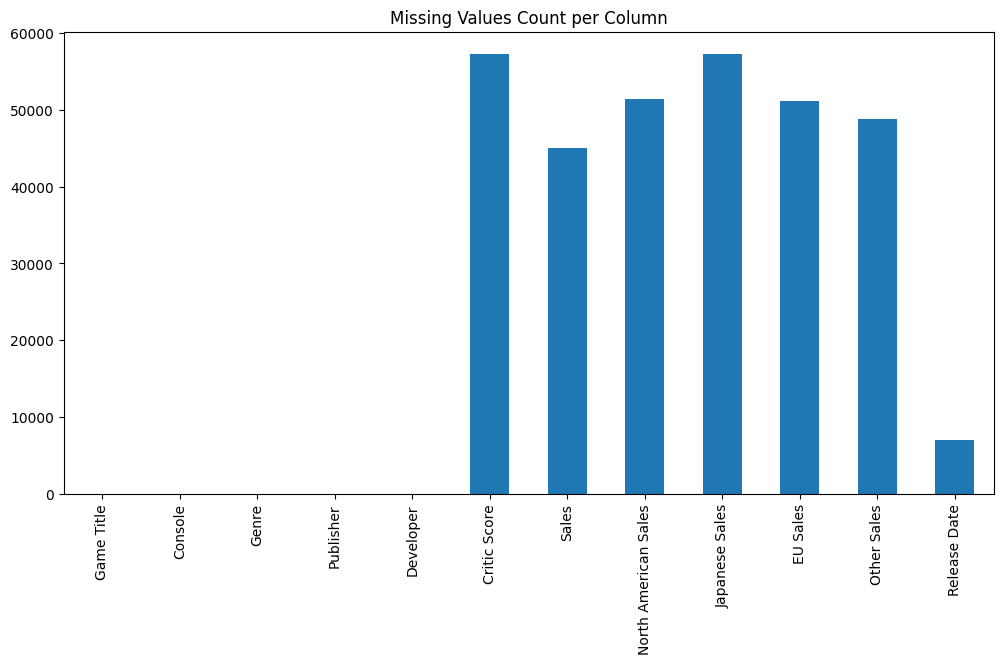

In [80]:
# Bar plot of missing values count per column
df.isnull().sum().plot(kind='bar', figsize=(12,6))
plt.title("Missing Values Count per Column")
plt.show()

In [81]:
# 1. Drop rows with missing target 
df = df.dropna(subset=['Sales'])

# 2. Fill categorical with "Unknown"
for col in ['Publisher','Developer','Genre','Console']:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# 3. Fill regional sales with 0
for col in ['North American Sales','Japanese Sales','EU Sales','Other Sales']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# 4. Critic Score -> fill with mean
if 'Critic Score' in df.columns:
    df['Critic Score'] = df['Critic Score'].fillna(df['Critic Score'].mean())

# 5. Release Date -> convert to year, fill missing with median
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')
df['Release Year'] = df['Release Date'].dt.year
df['Release Year'] = df['Release Year'].fillna(df['Release Year'].median())

df = df.drop(['Release Date'], axis=1)

df["Release Year"] = df["Release Year"].astype(int)

In [82]:
df.head()

,Game Title,Console,Genre,Publisher,Developer,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.40000,20.32,6.37,0.99,9.85,3.12,2013
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.70000,19.39,6.06,0.60,9.71,3.02,2014
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.60000,16.15,8.41,0.47,5.49,1.78,2002
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.10189,15.86,9.06,0.06,5.33,1.42,2013
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.10000,15.09,6.18,0.41,6.05,2.44,2015


In [83]:
df.count() # count rows

Game Title              18919
Console                 18919
Genre                   18919
Publisher               18919
Developer               18919
Critic Score            18919
Sales                   18919
North American Sales    18919
Japanese Sales          18919
EU Sales                18919
Other Sales             18919
Release Year            18919
dtype: int64

In [84]:
# Calculate regional sum for incorrection between Sales & Regional Sales
regional_sum = (df["North American Sales"] +
    df["Japanese Sales"] +
    df["EU Sales"] +
    df["Other Sales"]
)

# Replace Sales if regional sum is greater
df.loc[regional_sum > df["Sales"], "Sales"] = regional_sum

In [85]:
df.head()

,Game Title,Console,Genre,Publisher,Developer,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.40000,20.33,6.37,0.99,9.85,3.12,2013
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.70000,19.39,6.06,0.60,9.71,3.02,2014
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.60000,16.15,8.41,0.47,5.49,1.78,2002
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.10189,15.87,9.06,0.06,5.33,1.42,2013
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.10000,15.09,6.18,0.41,6.05,2.44,2015


In [86]:
df.dtypes # check data types

Game Title               object
Console                  object
Genre                    object
Publisher                object
Developer                object
Critic Score            float64
Sales                   float64
North American Sales    float64
Japanese Sales          float64
EU Sales                float64
Other Sales             float64
Release Year              int64
dtype: object

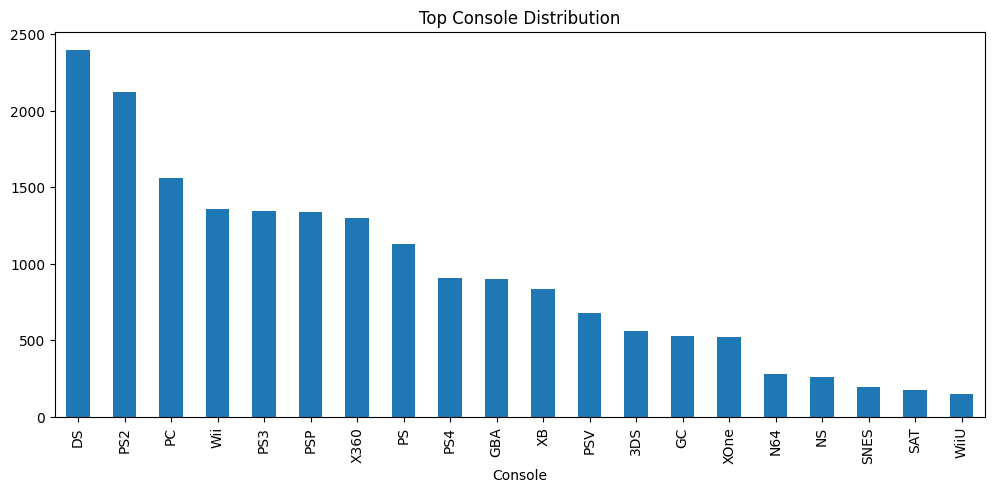

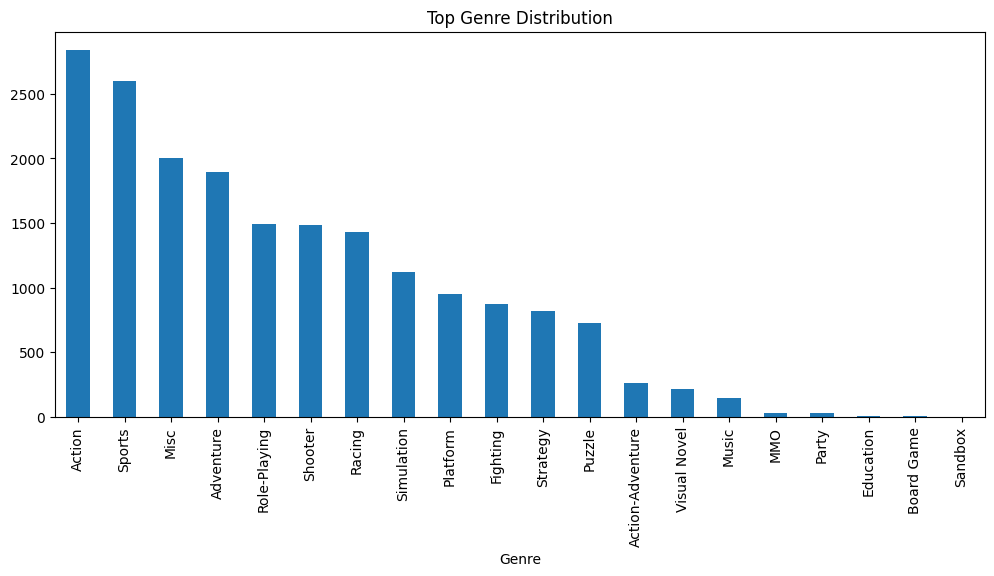

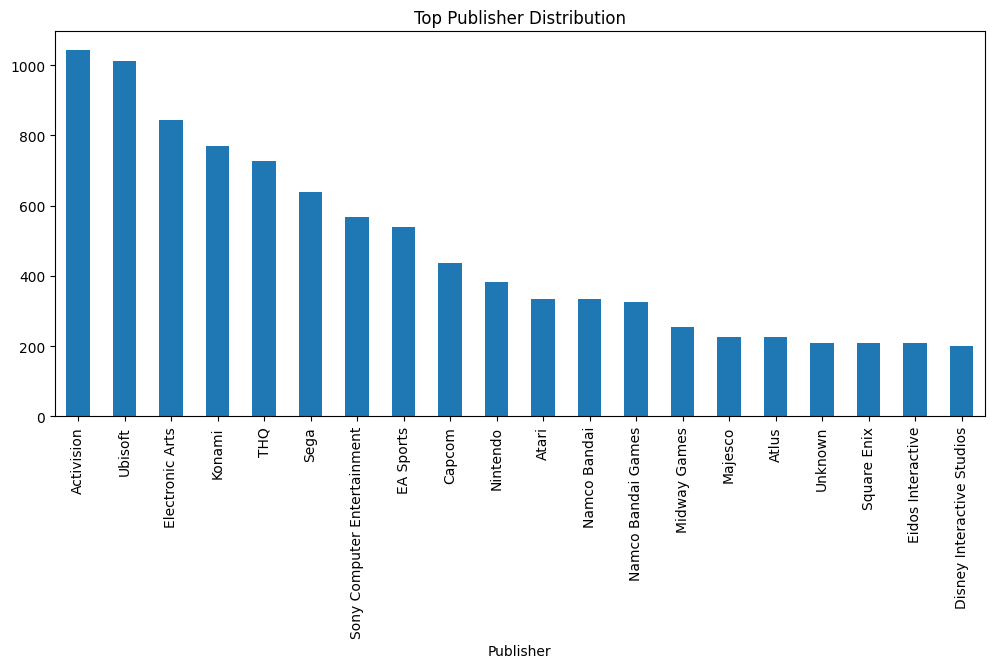

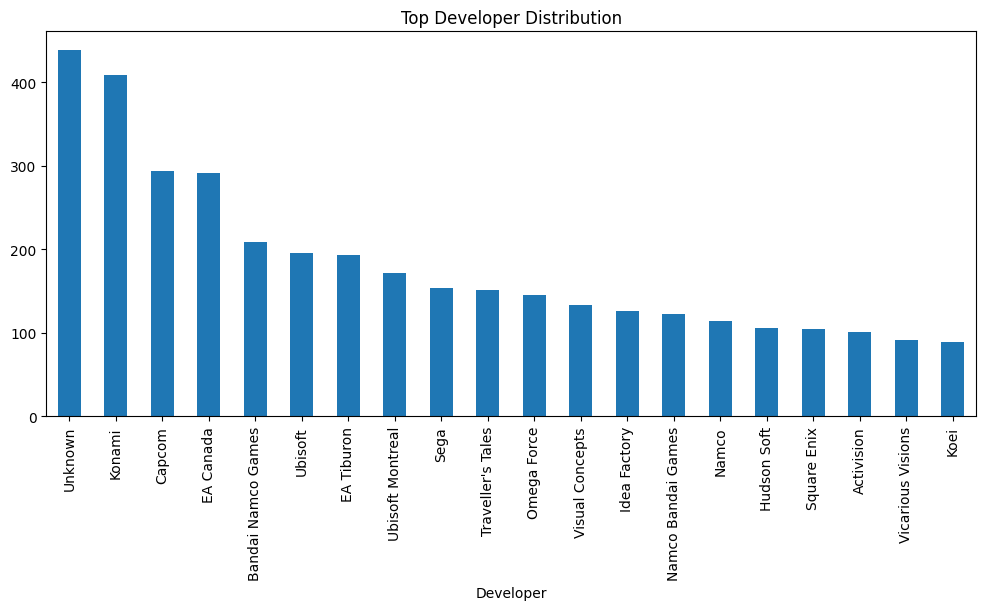

In [87]:
#Count of categorical values

for col in ["Console", "Genre", "Publisher", "Developer"]:
    plt.figure(figsize=(12,5))
    df[col].value_counts().head(20).plot(kind="bar")
    plt.title(f"Top {col} Distribution")
    plt.show()

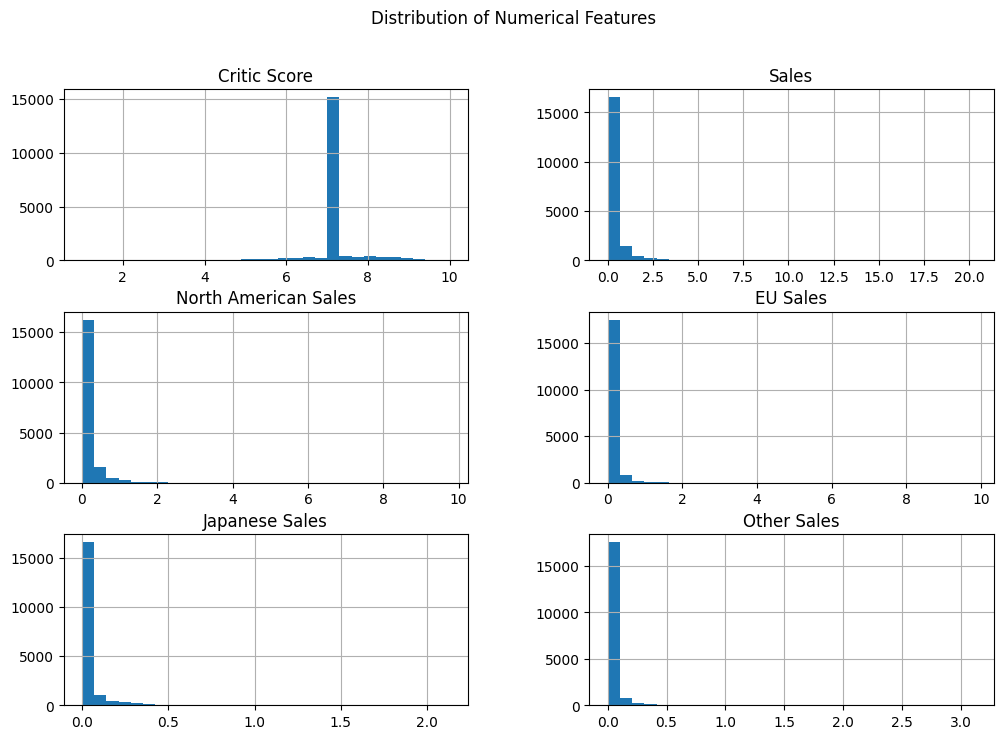

In [88]:
# Histogram of numerical columns

df[["Critic Score","Sales","North American Sales",
    "EU Sales","Japanese Sales","Other Sales"]].hist(figsize=(12,8), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.show()

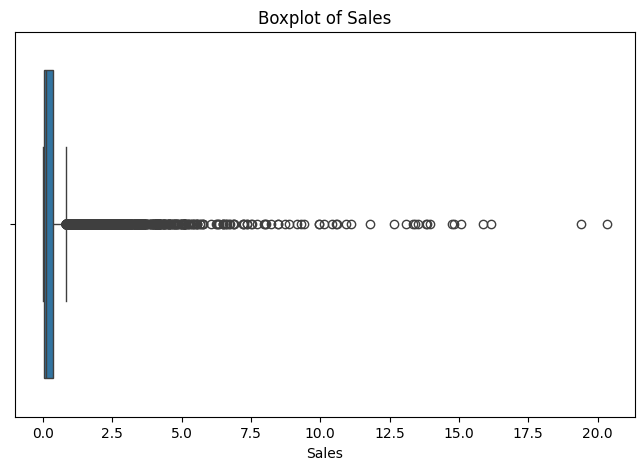

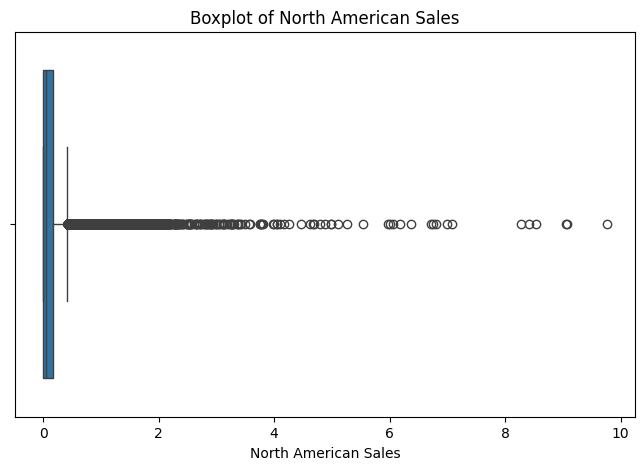

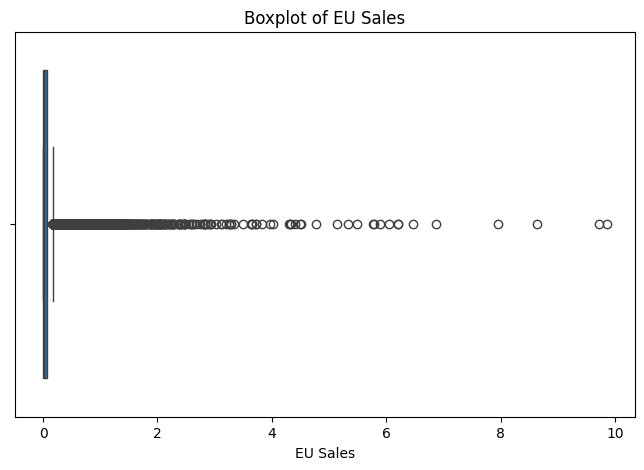

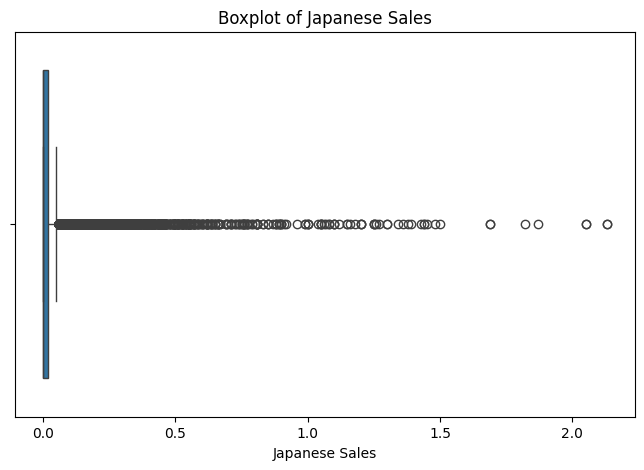

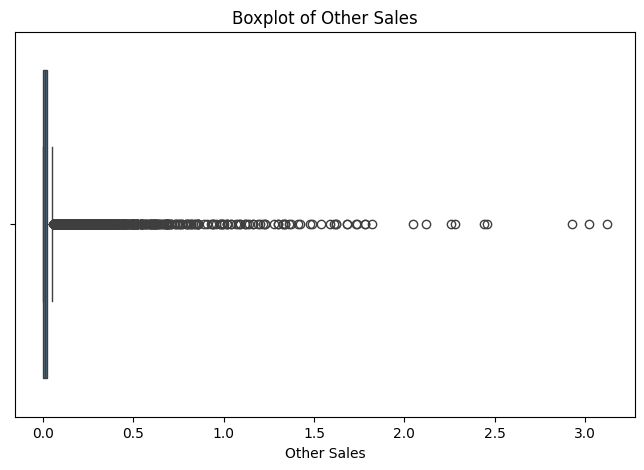

In [89]:
#Boxplot For Numerical Values 

for col in ["Sales","North American Sales","EU Sales","Japanese Sales","Other Sales"]:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

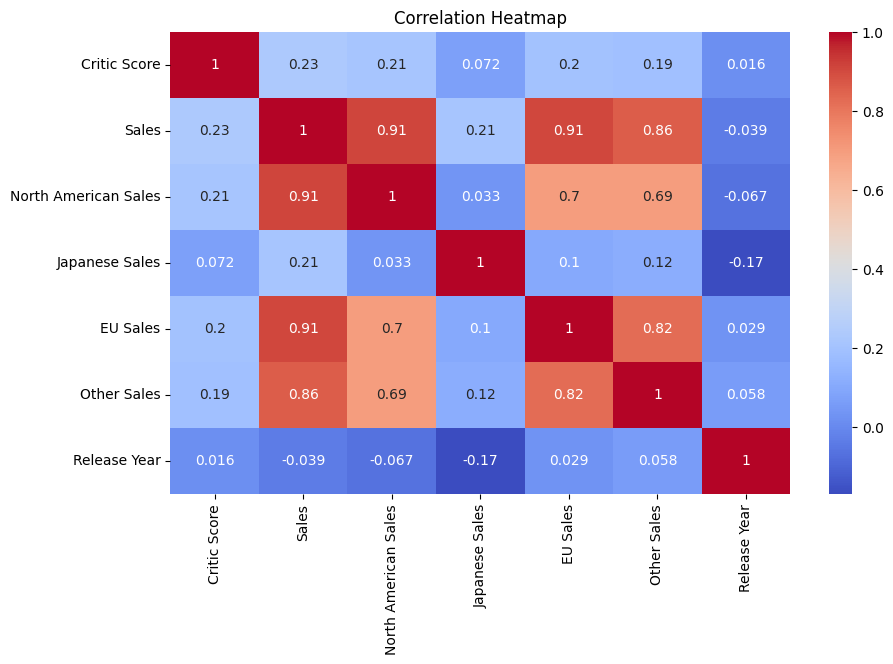

In [90]:
# Correlation heatmap (numerical columns)

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

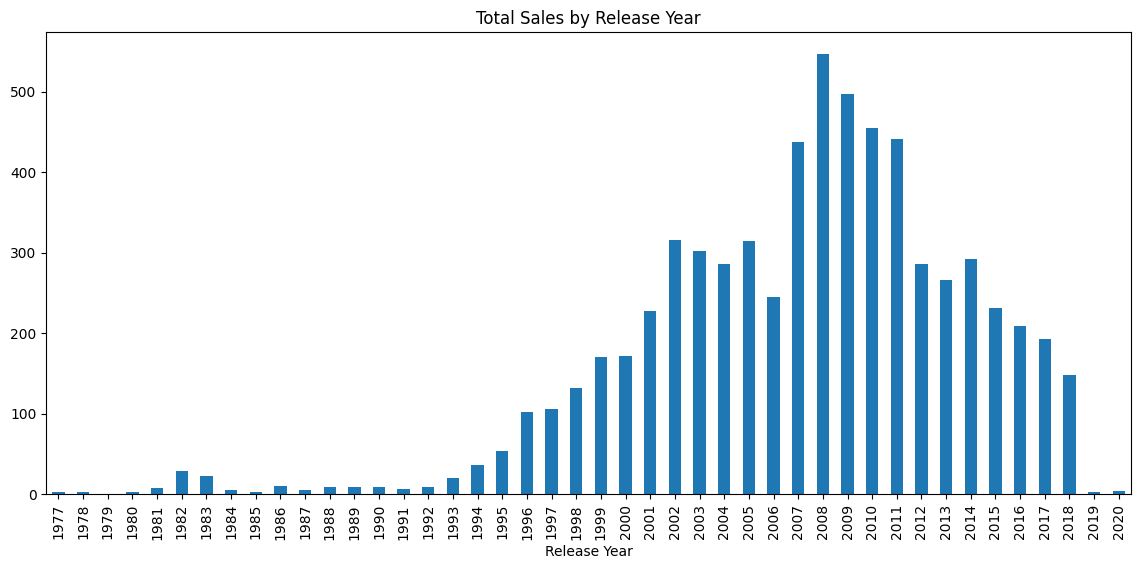

In [91]:
# Sales by release year

df.groupby("Release Year")["Sales"].sum().plot(kind="bar", figsize=(14,6))
plt.title("Total Sales by Release Year")
plt.show()

In [92]:
# 2.Encoding & Outlier Removal

In [93]:
df.head()

,Game Title,Console,Genre,Publisher,Developer,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.40000,20.33,6.37,0.99,9.85,3.12,2013
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.70000,19.39,6.06,0.60,9.71,3.02,2014
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.60000,16.15,8.41,0.47,5.49,1.78,2002
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.10189,15.87,9.06,0.06,5.33,1.42,2013
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.10000,15.09,6.18,0.41,6.05,2.44,2015


In [94]:
df.head()

,Game Title,Console,Genre,Publisher,Developer,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.40000,20.33,6.37,0.99,9.85,3.12,2013
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.70000,19.39,6.06,0.60,9.71,3.02,2014
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.60000,16.15,8.41,0.47,5.49,1.78,2002
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.10189,15.87,9.06,0.06,5.33,1.42,2013
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.10000,15.09,6.18,0.41,6.05,2.44,2015


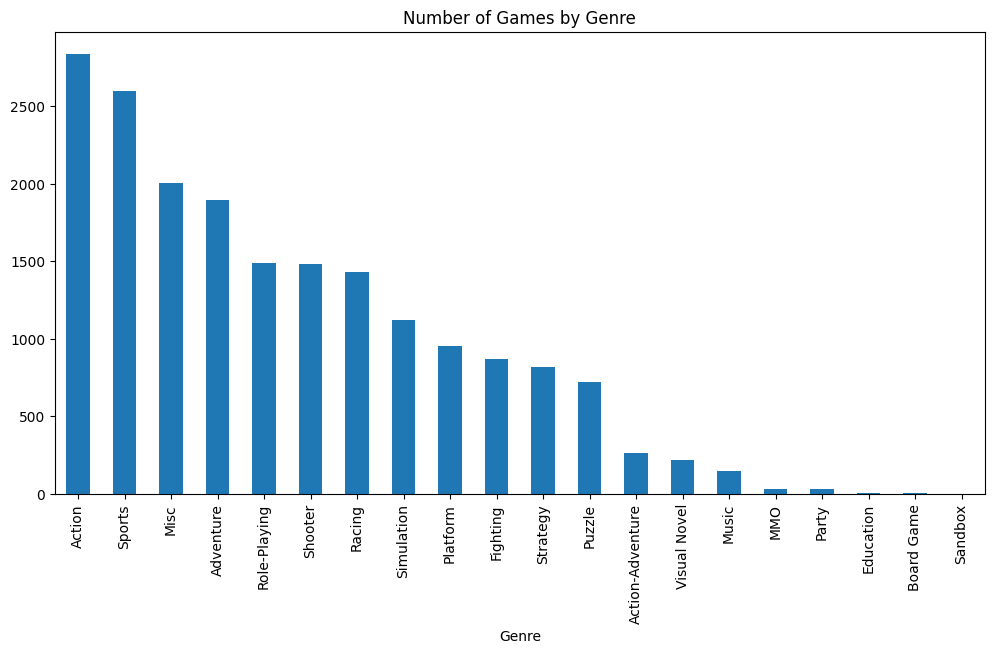

In [95]:
# Genre counts

df["Genre"].value_counts().plot(kind="bar", figsize=(12,6))
plt.title("Number of Games by Genre")
plt.show()

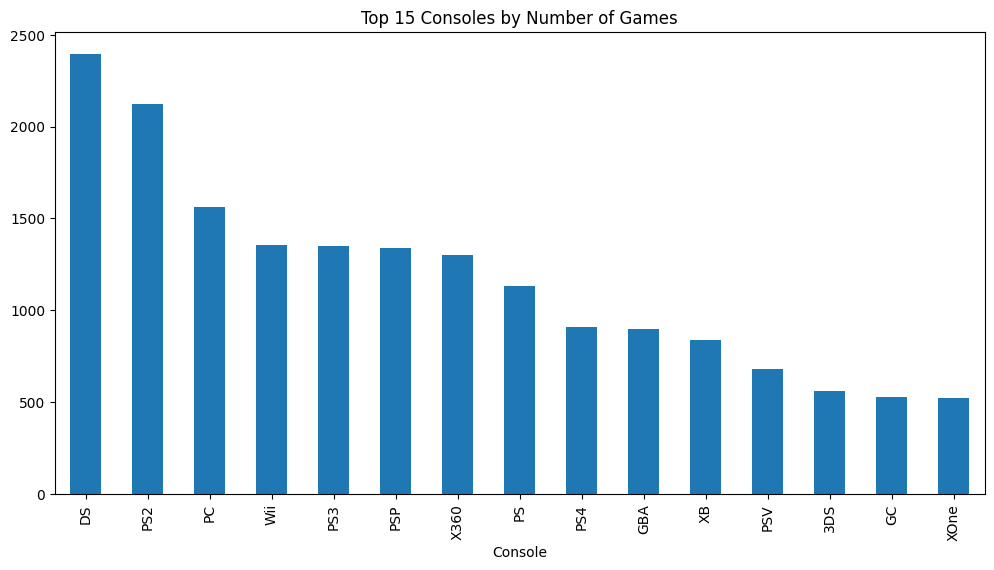

In [96]:
# Top 15 Colnsoles by Sales

df["Console"].value_counts().head(15).plot(kind="bar", figsize=(12,6))
plt.title("Top 15 Consoles by Number of Games")
plt.show()

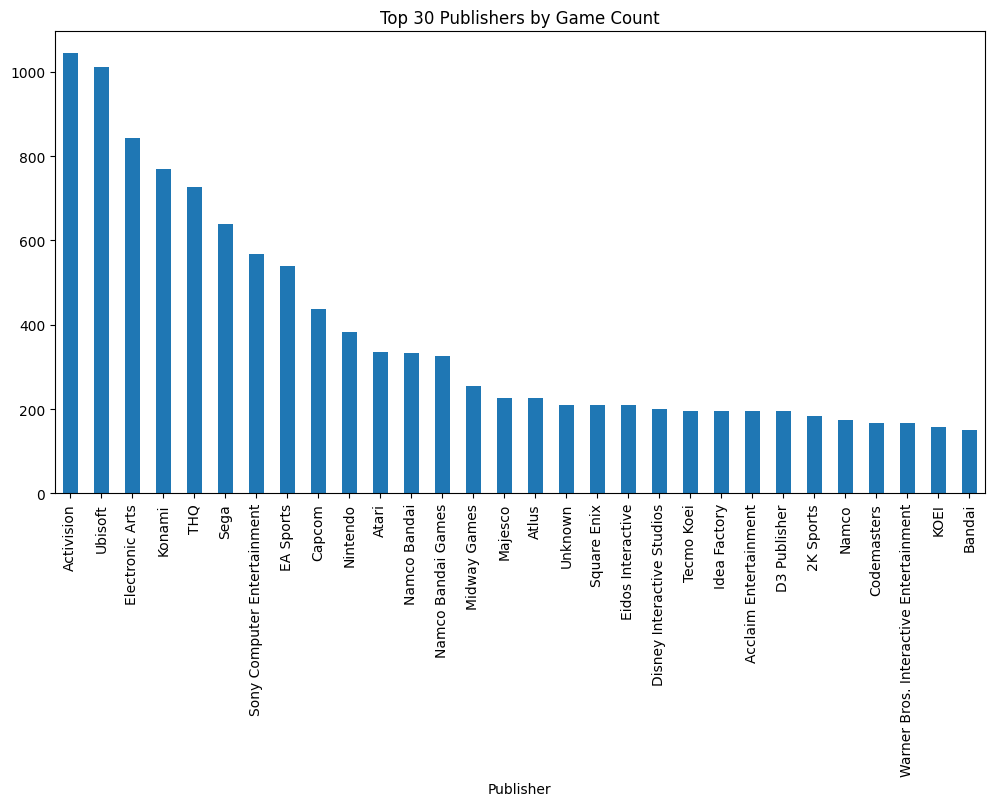

In [97]:
# Top 30 Publishers 

df["Publisher"].value_counts().head(30).plot(kind="bar", figsize=(12,6))
plt.title("Top 30 Publishers by Game Count")
plt.show()

In [98]:
# One-hot encode Genre & Platform
df = pd.get_dummies(df, columns=['Genre','Console'], drop_first=True)

# For Publisher/Developer, keep top 30 and label others as "Other"
def cap_top(series, n=30):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), "Other")

df['Publisher'] = cap_top(df['Publisher'])
df['Developer'] = cap_top(df['Developer'])

# One-hot encode after capping
df = pd.get_dummies(df, columns=['Publisher','Developer'], drop_first=True)

In [99]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Genre_Action-Adventure,Genre_Adventure,...,Developer_Other,Developer_Sega,Developer_Square Enix,Developer_THQ,Developer_Traveller's Tales,Developer_Ubisoft,Developer_Ubisoft Montreal,Developer_Unknown,Developer_Vicarious Visions,Developer_Visual Concepts
0,Grand Theft Auto V,9.40000,20.33,6.37,0.99,9.85,3.12,2013,False,False,...,True,False,False,False,False,False,False,False,False,False
1,Grand Theft Auto V,9.70000,19.39,6.06,0.60,9.71,3.02,2014,False,False,...,True,False,False,False,False,False,False,False,False,False
2,Grand Theft Auto: Vice City,9.60000,16.15,8.41,0.47,5.49,1.78,2002,False,False,...,True,False,False,False,False,False,False,False,False,False
3,Grand Theft Auto V,7.10189,15.87,9.06,0.06,5.33,1.42,2013,False,False,...,True,False,False,False,False,False,False,False,False,False
4,Call of Duty: Black Ops 3,8.10000,15.09,6.18,0.41,6.05,2.44,2015,False,False,...,True,False,False,False,False,False,False,False,False,False


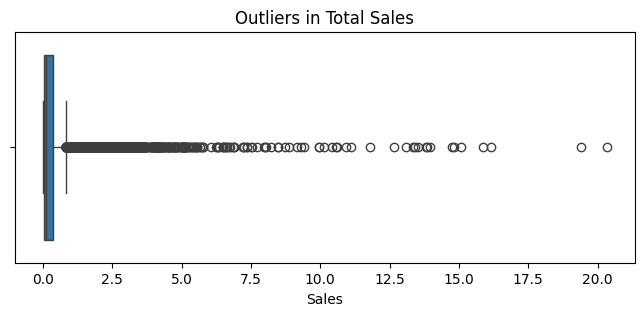

In [100]:
# Outliers for Total Sales 

plt.figure(figsize=(8,3))
sns.boxplot(x=df['Sales'])
plt.title("Outliers in Total Sales")
plt.show()

In [101]:
# Assume your dataframe is named df and 'Sales' is numeric.

# 1) Compute IQR and bounds
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Sales can't be negative; use 0 as the practical minimum
lower_cutoff = max(0, lower_bound)

print(f"Q1={Q1:.3f}, Q3={Q3:.3f}, IQR={IQR:.3f}")
print(f"Lower bound (IQR)={lower_bound:.3f} → using cutoff={lower_cutoff:.3f}")
print(f"Upper bound (IQR)={upper_bound:.3f}")

# 2) Detect outliers
lower_outliers = df["Sales"] < lower_cutoff
upper_outliers = df["Sales"] > upper_bound

print("Lower-bound outliers:", lower_outliers.sum())
print("Upper-bound outliers (kept):", upper_outliers.sum())

# 3) Remove ONLY lower-bound outliers
df = df[~lower_outliers].copy() 
df = df[df["Sales"] > 0].copy()

Q1=0.030, Q3=0.350, IQR=0.320
Lower bound (IQR)=-0.450 → using cutoff=0.000
Upper bound (IQR)=0.830
Lower-bound outliers: 0
Upper-bound outliers (kept): 1911


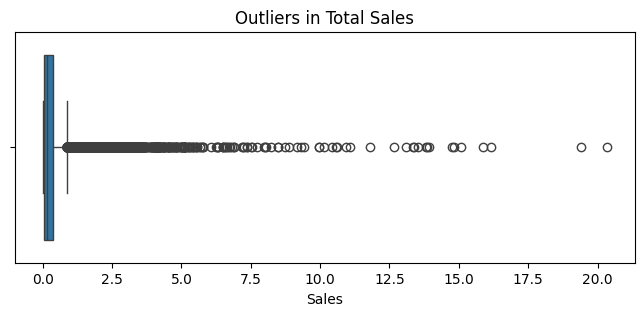

In [102]:
# Outliers for Total Sales 

plt.figure(figsize=(8,3))
sns.boxplot(x=df['Sales'])
plt.title("Outliers in Total Sales")
plt.show()

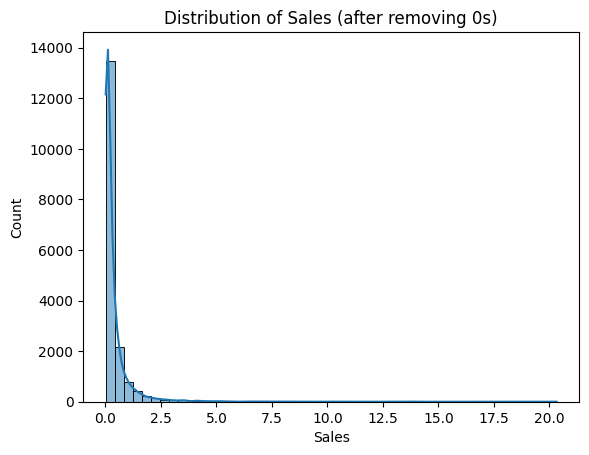

In [103]:
# Histogram for Sales Ater Outlier removal

sns.histplot(df["Sales"], bins=50, kde=True)
plt.title("Distribution of Sales (after removing 0s)")
plt.show()

In [104]:
# 3.Scaling & Normalization

In [105]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Genre_Action-Adventure,Genre_Adventure,...,Developer_Other,Developer_Sega,Developer_Square Enix,Developer_THQ,Developer_Traveller's Tales,Developer_Ubisoft,Developer_Ubisoft Montreal,Developer_Unknown,Developer_Vicarious Visions,Developer_Visual Concepts
0,Grand Theft Auto V,9.40000,20.33,6.37,0.99,9.85,3.12,2013,False,False,...,True,False,False,False,False,False,False,False,False,False
1,Grand Theft Auto V,9.70000,19.39,6.06,0.60,9.71,3.02,2014,False,False,...,True,False,False,False,False,False,False,False,False,False
2,Grand Theft Auto: Vice City,9.60000,16.15,8.41,0.47,5.49,1.78,2002,False,False,...,True,False,False,False,False,False,False,False,False,False
3,Grand Theft Auto V,7.10189,15.87,9.06,0.06,5.33,1.42,2013,False,False,...,True,False,False,False,False,False,False,False,False,False
4,Call of Duty: Black Ops 3,8.10000,15.09,6.18,0.41,6.05,2.44,2015,False,False,...,True,False,False,False,False,False,False,False,False,False


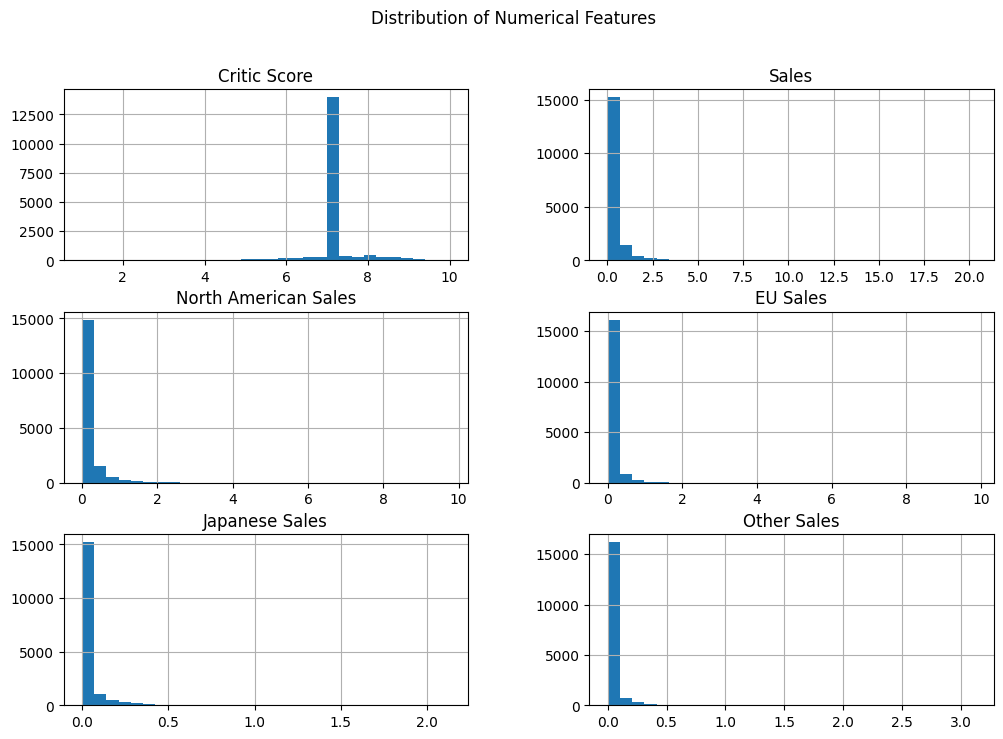

In [106]:
# Histogram of numerical columns

df[["Critic Score","Sales","North American Sales",
    "EU Sales","Japanese Sales","Other Sales"]].hist(figsize=(12,8), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.show()

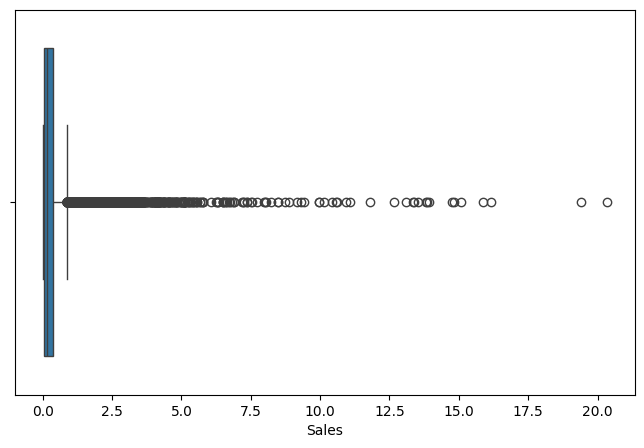

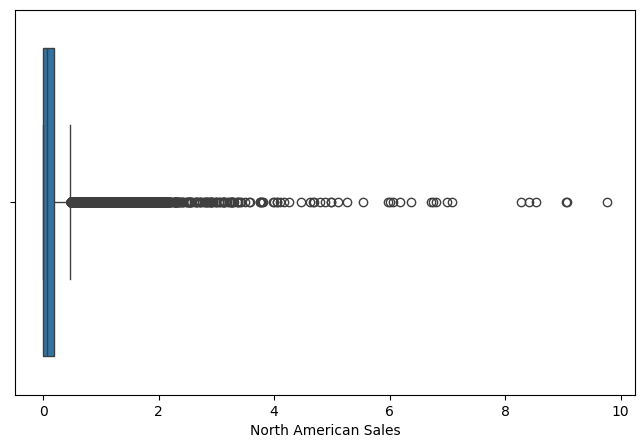

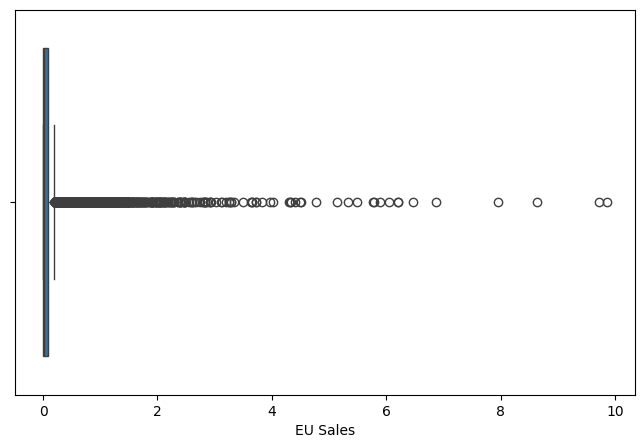

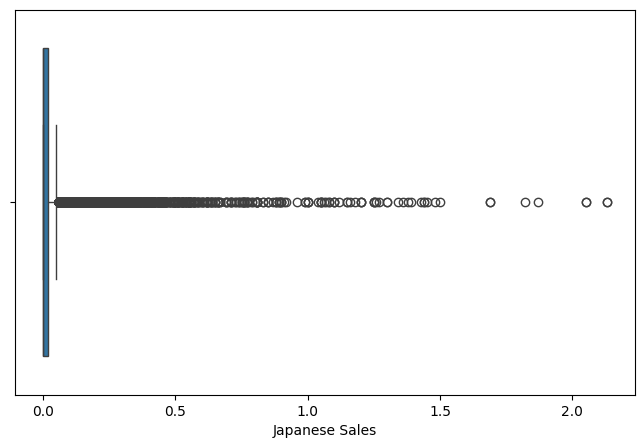

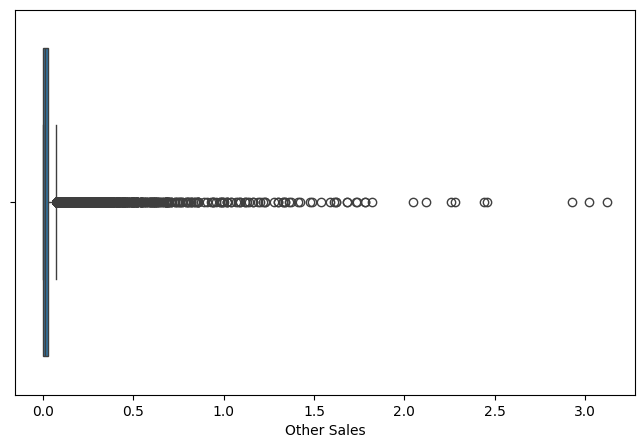

In [107]:
#Boxplot For Numerical Values 

for col in ["Sales","North American Sales","EU Sales","Japanese Sales","Other Sales"]:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df[col])

In [108]:
# Scale Critic Score between 0-1 ( Normalization )
scaler = MinMaxScaler()

# Scale critic score only (keep Sales as original for prediction target)
df['Critic Score'] = scaler.fit_transform(df[['Critic Score']])

In [109]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Genre_Action-Adventure,Genre_Adventure,...,Developer_Other,Developer_Sega,Developer_Square Enix,Developer_THQ,Developer_Traveller's Tales,Developer_Ubisoft,Developer_Ubisoft Montreal,Developer_Unknown,Developer_Vicarious Visions,Developer_Visual Concepts
0,Grand Theft Auto V,0.933333,20.33,6.37,0.99,9.85,3.12,2013,False,False,...,True,False,False,False,False,False,False,False,False,False
1,Grand Theft Auto V,0.966667,19.39,6.06,0.60,9.71,3.02,2014,False,False,...,True,False,False,False,False,False,False,False,False,False
2,Grand Theft Auto: Vice City,0.955556,16.15,8.41,0.47,5.49,1.78,2002,False,False,...,True,False,False,False,False,False,False,False,False,False
3,Grand Theft Auto V,0.677988,15.87,9.06,0.06,5.33,1.42,2013,False,False,...,True,False,False,False,False,False,False,False,False,False
4,Call of Duty: Black Ops 3,0.788889,15.09,6.18,0.41,6.05,2.44,2015,False,False,...,True,False,False,False,False,False,False,False,False,False


In [110]:
df.shape # check dimentions

(17567, 125)

In [111]:
# Scale Sales & Regional Sales between 0-1 
# Define the sales columns 
sales_cols = ['Sales', 'North American Sales', 'EU Sales', 'Japanese Sales', 'Other Sales']

scaler = MinMaxScaler()

# Fit + transform the sales columns
df[sales_cols] = scaler.fit_transform(df[sales_cols])

In [112]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Genre_Action-Adventure,Genre_Adventure,...,Developer_Other,Developer_Sega,Developer_Square Enix,Developer_THQ,Developer_Traveller's Tales,Developer_Ubisoft,Developer_Ubisoft Montreal,Developer_Unknown,Developer_Vicarious Visions,Developer_Visual Concepts
0,Grand Theft Auto V,0.933333,1.000000,0.652664,0.464789,1.000000,1.000000,2013,False,False,...,True,False,False,False,False,False,False,False,False,False
1,Grand Theft Auto V,0.966667,0.953740,0.620902,0.281690,0.985787,0.967949,2014,False,False,...,True,False,False,False,False,False,False,False,False,False
2,Grand Theft Auto: Vice City,0.955556,0.794291,0.861680,0.220657,0.557360,0.570513,2002,False,False,...,True,False,False,False,False,False,False,False,False,False
3,Grand Theft Auto V,0.677988,0.780512,0.928279,0.028169,0.541117,0.455128,2013,False,False,...,True,False,False,False,False,False,False,False,False,False
4,Call of Duty: Black Ops 3,0.788889,0.742126,0.633197,0.192488,0.614213,0.782051,2015,False,False,...,True,False,False,False,False,False,False,False,False,False


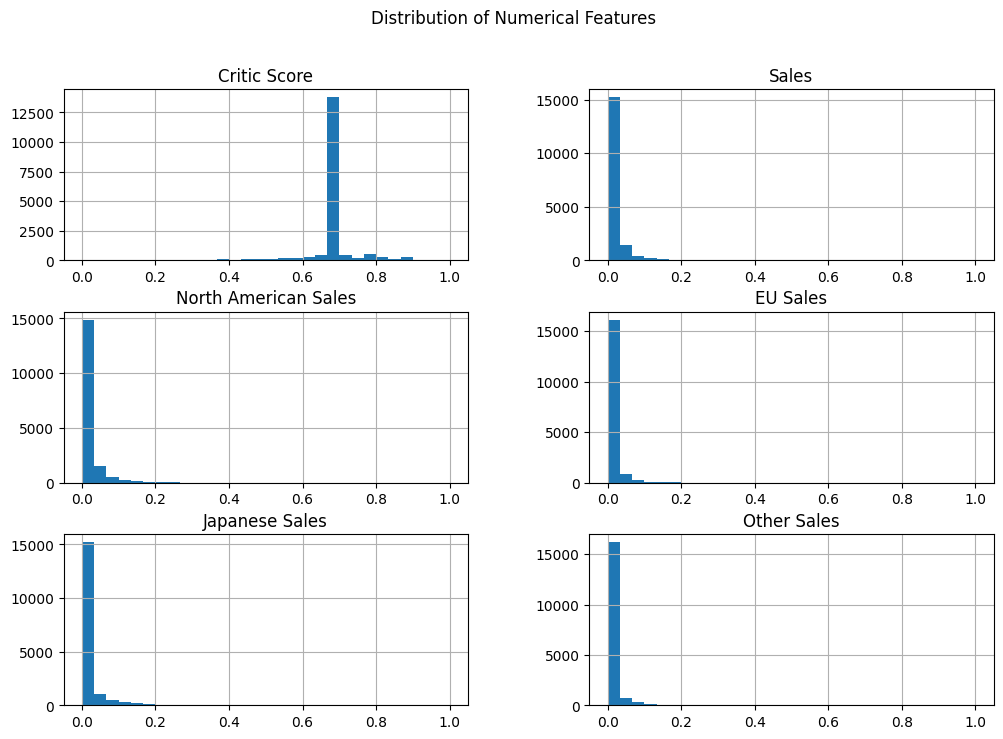

In [113]:
# Histogram of numerical columns

df[["Critic Score","Sales","North American Sales",
    "EU Sales","Japanese Sales","Other Sales"]].hist(figsize=(12,8), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.show()

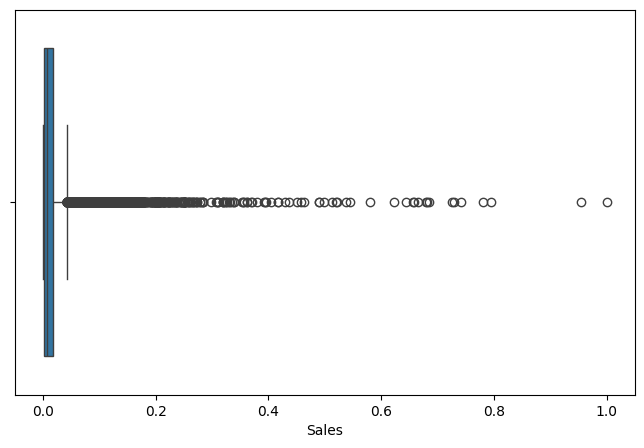

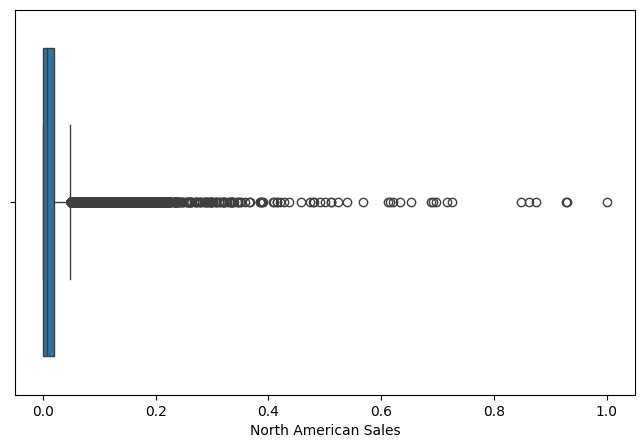

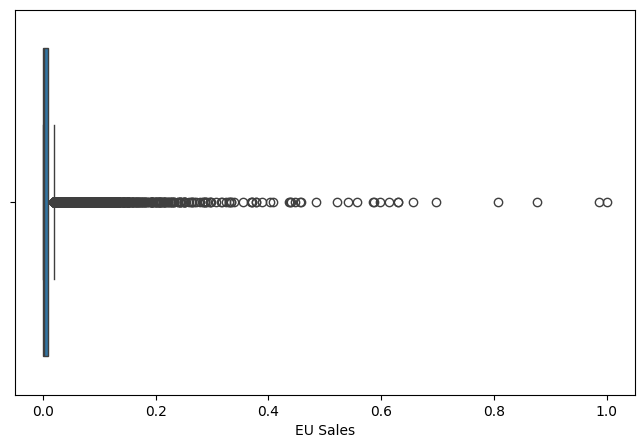

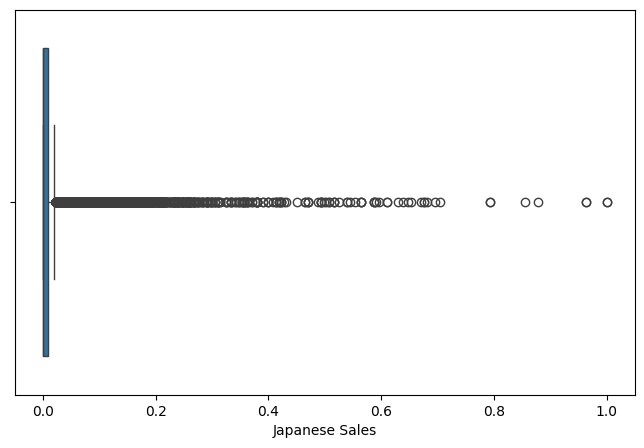

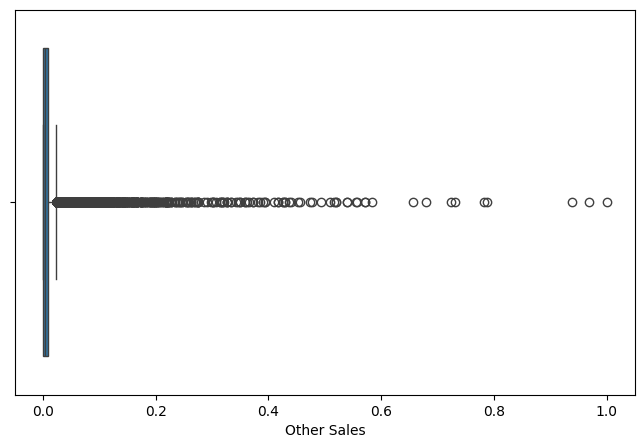

In [114]:
#Boxplot For Numerical Values 

for col in ["Sales","North American Sales","EU Sales","Japanese Sales","Other Sales"]:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df[col])

In [121]:
# 4.Feature Engineering 

In [122]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Genre_Action-Adventure,Genre_Adventure,...,Developer_Other,Developer_Sega,Developer_Square Enix,Developer_THQ,Developer_Traveller's Tales,Developer_Ubisoft,Developer_Ubisoft Montreal,Developer_Unknown,Developer_Vicarious Visions,Developer_Visual Concepts
0,Grand Theft Auto V,0.933333,1.000000,0.652664,0.464789,1.000000,1.000000,2013,False,False,...,True,False,False,False,False,False,False,False,False,False
1,Grand Theft Auto V,0.966667,0.953740,0.620902,0.281690,0.985787,0.967949,2014,False,False,...,True,False,False,False,False,False,False,False,False,False
2,Grand Theft Auto: Vice City,0.955556,0.794291,0.861680,0.220657,0.557360,0.570513,2002,False,False,...,True,False,False,False,False,False,False,False,False,False
3,Grand Theft Auto V,0.677988,0.780512,0.928279,0.028169,0.541117,0.455128,2013,False,False,...,True,False,False,False,False,False,False,False,False,False
4,Call of Duty: Black Ops 3,0.788889,0.742126,0.633197,0.192488,0.614213,0.782051,2015,False,False,...,True,False,False,False,False,False,False,False,False,False


In [123]:
df.dtypes # check data types

Game Title                      object
Critic Score                   float64
Sales                          float64
North American Sales           float64
Japanese Sales                 float64
                                ...   
Developer_Ubisoft                 bool
Developer_Ubisoft Montreal        bool
Developer_Unknown                 bool
Developer_Vicarious Visions       bool
Developer_Visual Concepts         bool
Length: 125, dtype: object

In [124]:
# Create decade column
df['Decade'] = (df['Release Year'] // 10) * 10

# Percentages of sales per region 
df['NA Share'] = df['North American Sales'] / df['Sales']
df['EU Share'] = df['EU Sales'] / df['Sales']
df['JP Share'] = df['Japanese Sales'] / df['Sales']
df['Other Share'] = df['Other Sales'] / df['Sales']

# New Game ?
df['Is Recent'] = df['Release Year'].apply(lambda x: 1 if x >= 2015 else 0)

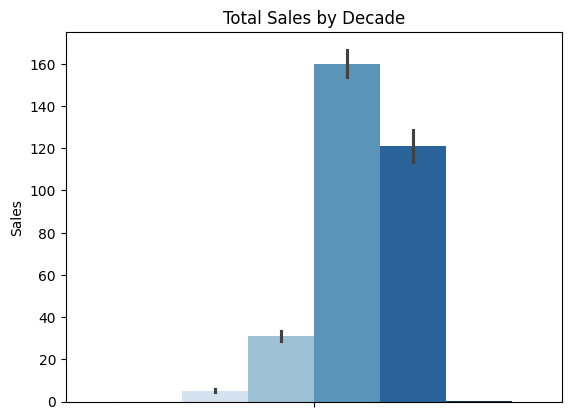

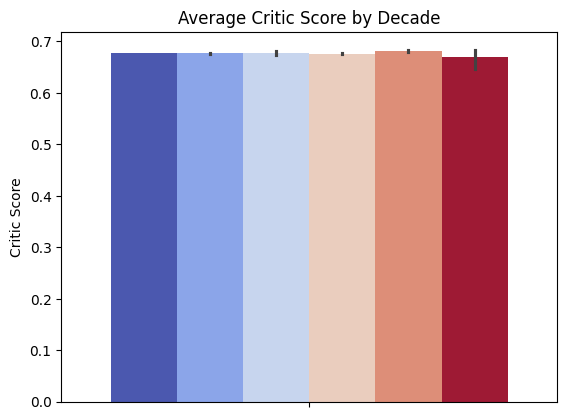

In [125]:
# Check sales trends across decades

sns.barplot(hue="Decade", y="Sales", data=df, estimator="sum", palette="Blues", legend=False)
plt.title("Total Sales by Decade")
plt.show()

sns.barplot(hue="Decade", y="Critic Score", data=df, estimator="mean", palette="coolwarm", legend=False)
plt.title("Average Critic Score by Decade")
plt.show()

In [126]:
# Bins and labels
bins = [0, 0.3, 0.7, 1.0]          # cut points
labels = ["Low", "Medium", "High"] # category names

# New Game Quality column 
df["Game Quality"] = pd.cut(df["Critic Score"], bins=bins, labels=labels, include_lowest=True)

# Label Encode categories as integers
encoding_map = {"Low": 0, "Medium": 1, "High": 2}
df["Game Quality Encoded"] = df["Game Quality"].map(encoding_map)

# check
print(df[["Critic Score", "Game Quality", "Game Quality Encoded"]].head(20))

    Critic Score Game Quality Game Quality Encoded
0       0.933333         High                    2
1       0.966667         High                    2
2       0.955556         High                    2
3       0.677988       Medium                    1
4       0.788889         High                    2
5       0.855556         High                    2
6       0.866667         High                    2
7       0.977778         High                    2
8       0.822222         High                    2
9       0.777778         High                    2
10      0.944444         High                    2
11      0.788889         High                    2
12      0.866667         High                    2
13      0.944444         High                    2
14      0.855556         High                    2
15      0.811111         High                    2
16      1.000000         High                    2
17      0.877778         High                    2
18      0.944444         High  

In [127]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Genre_Action-Adventure,Genre_Adventure,...,Developer_Vicarious Visions,Developer_Visual Concepts,Decade,NA Share,EU Share,JP Share,Other Share,Is Recent,Game Quality,Game Quality Encoded
0,Grand Theft Auto V,0.933333,1.000000,0.652664,0.464789,1.000000,1.000000,2013,False,False,...,False,False,2010,0.652664,1.000000,0.464789,1.000000,0,High,2
1,Grand Theft Auto V,0.966667,0.953740,0.620902,0.281690,0.985787,0.967949,2014,False,False,...,False,False,2010,0.651018,1.033601,0.295353,1.014898,0,High,2
2,Grand Theft Auto: Vice City,0.955556,0.794291,0.861680,0.220657,0.557360,0.570513,2002,False,False,...,False,False,2000,1.084842,0.701708,0.277804,0.718266,0,High,2
3,Grand Theft Auto V,0.677988,0.780512,0.928279,0.028169,0.541117,0.455128,2013,False,False,...,False,False,2010,1.189320,0.693285,0.036090,0.583115,0,Medium,1
4,Call of Duty: Black Ops 3,0.788889,0.742126,0.633197,0.192488,0.614213,0.782051,2015,False,False,...,False,False,2010,0.853220,0.827640,0.259374,1.053799,1,High,2


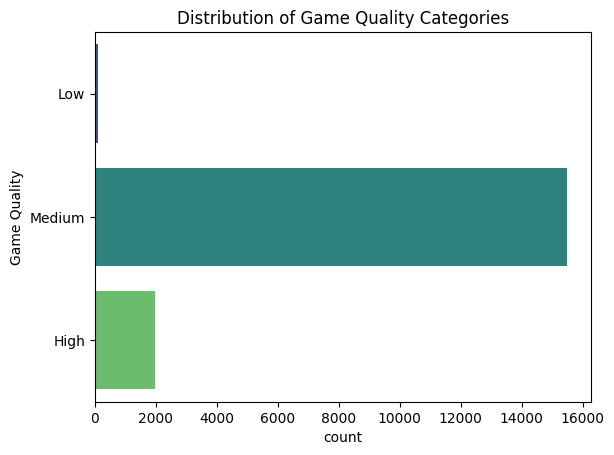

In [128]:
# Distribution of Game Quality

sns.countplot(hue="Game Quality", y="Game Quality", data=df, palette="viridis", legend=False)
plt.title("Distribution of Game Quality Categories")
plt.show()

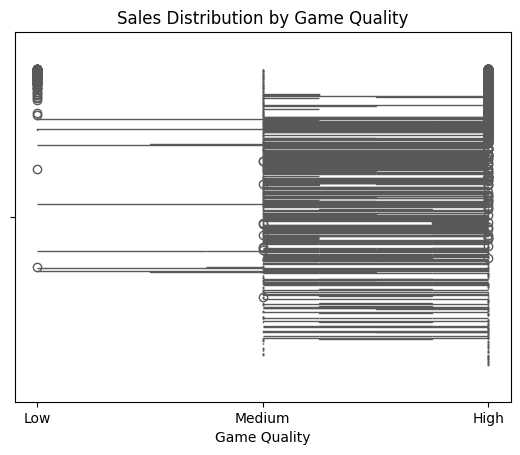

In [129]:
sns.boxplot(x="Game Quality", hue="Sales", data=df, palette="Set2", legend=False)
plt.title("Sales Distribution by Game Quality")
plt.show()

In [139]:
# 5.Feature Selection

In [133]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Genre_Action-Adventure,Genre_Adventure,...,Developer_Vicarious Visions,Developer_Visual Concepts,Decade,NA Share,EU Share,JP Share,Other Share,Is Recent,Game Quality,Game Quality Encoded
0,Grand Theft Auto V,0.933333,1.000000,0.652664,0.464789,1.000000,1.000000,2013,False,False,...,False,False,2010,0.652664,1.000000,0.464789,1.000000,0,High,2
1,Grand Theft Auto V,0.966667,0.953740,0.620902,0.281690,0.985787,0.967949,2014,False,False,...,False,False,2010,0.651018,1.033601,0.295353,1.014898,0,High,2
2,Grand Theft Auto: Vice City,0.955556,0.794291,0.861680,0.220657,0.557360,0.570513,2002,False,False,...,False,False,2000,1.084842,0.701708,0.277804,0.718266,0,High,2
3,Grand Theft Auto V,0.677988,0.780512,0.928279,0.028169,0.541117,0.455128,2013,False,False,...,False,False,2010,1.189320,0.693285,0.036090,0.583115,0,Medium,1
4,Call of Duty: Black Ops 3,0.788889,0.742126,0.633197,0.192488,0.614213,0.782051,2015,False,False,...,False,False,2010,0.853220,0.827640,0.259374,1.053799,1,High,2


In [134]:
df.dtypes # check data types

Game Title                object
Critic Score             float64
Sales                    float64
North American Sales     float64
Japanese Sales           float64
                          ...   
JP Share                 float64
Other Share              float64
Is Recent                  int64
Game Quality            category
Game Quality Encoded    category
Length: 133, dtype: object

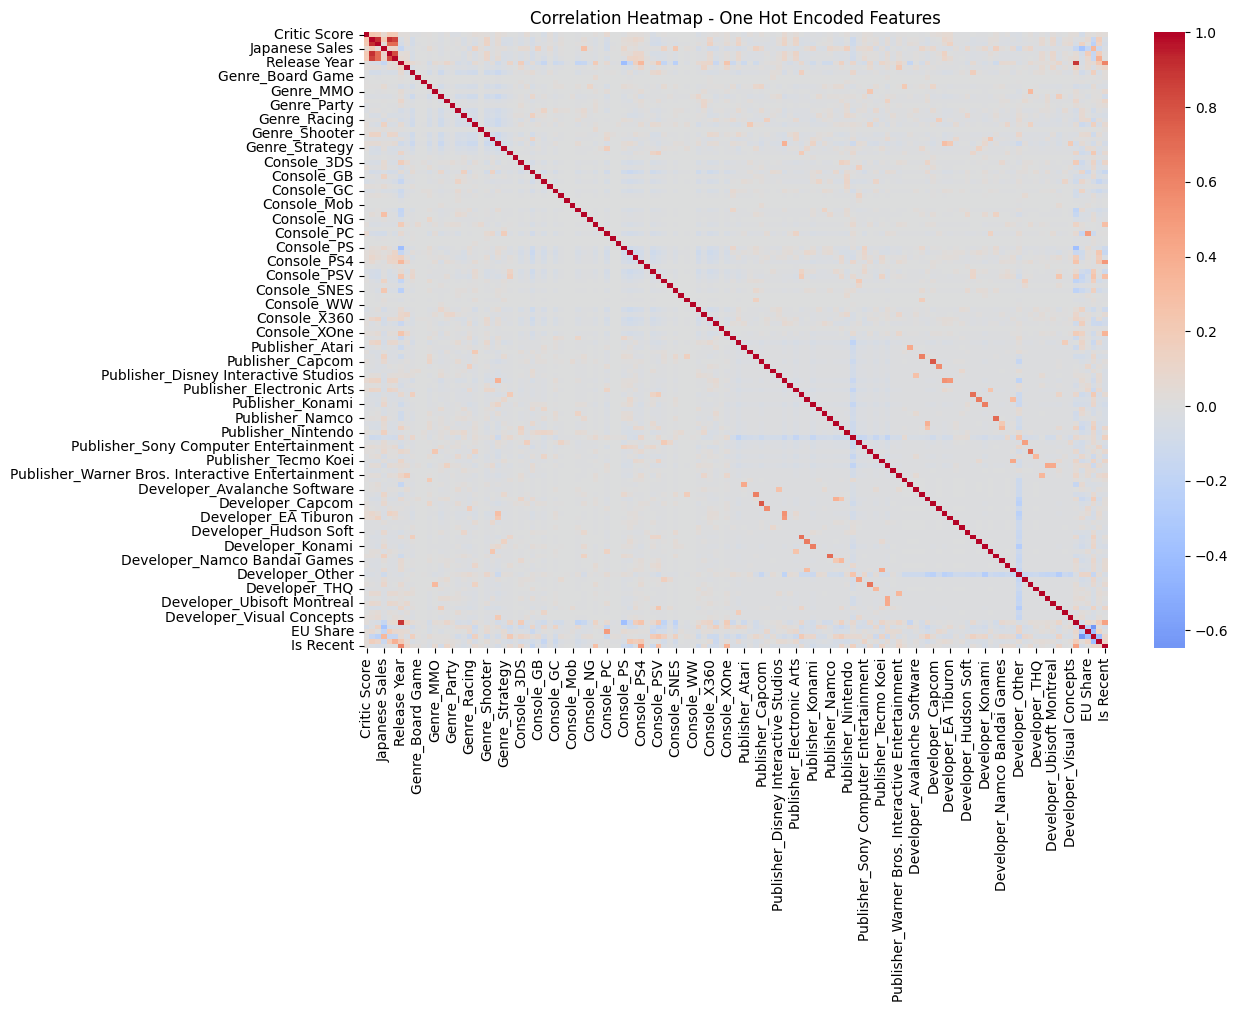

In [135]:
# Correlation Heatmap (EDA step)

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - One Hot Encoded Features")
plt.show()

In [136]:
# Variance Threshold

X = df.drop(columns=["Sales"]).select_dtypes(include="number").copy()
y = df["Sales"].astype(float)

# make it finite + numeric
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

vt = VarianceThreshold(threshold=0.001)
X_vt = X.loc[:, vt.fit(X).get_support()]

print("Original features:", X.shape[1])
print("After VarianceThreshold:", X_vt.shape[1])

Original features: 12
After VarianceThreshold: 12


Top MI features:
 Other Share             1.914154
NA Share                1.442209
EU Share                1.376849
North American Sales    1.146669
JP Share                0.781102
Other Sales             0.755550
EU Sales                0.707339
Japanese Sales          0.578838
Critic Score            0.065160
Release Year            0.051523
Decade                  0.020765
Is Recent               0.013843
dtype: float64


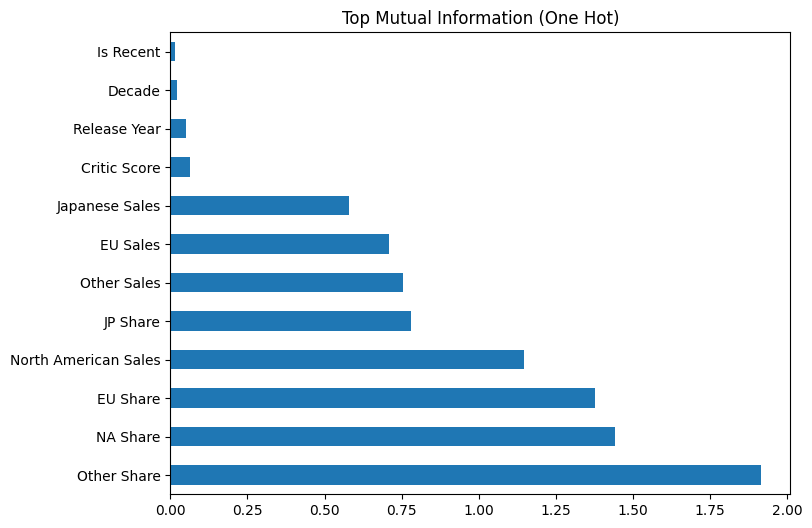

In [137]:
# Mutual Information

mi = mutual_info_regression(X_vt.fillna(0), y)
mi_scores = pd.Series(mi, index=X_vt.columns).sort_values(ascending=False)

print("Top MI features:\n", mi_scores.head(15))

mi_scores.head(15).plot(kind="barh", figsize=(8,6), title="Top Mutual Information (One Hot)")
plt.show()

Top RF features:
 EU Sales                0.494304
North American Sales    0.365335
Other Sales             0.109431
Japanese Sales          0.014219
NA Share                0.007131
EU Share                0.003825
Other Share             0.001945
JP Share                0.001536
Critic Score            0.001182
Release Year            0.000875
Decade                  0.000111
Is Recent               0.000104
dtype: float64


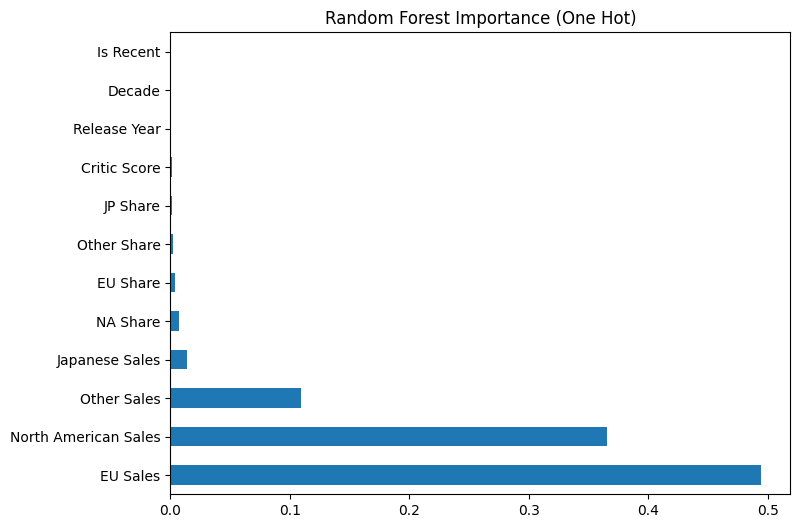

In [138]:
# Random Forest Importance

X_train, X_test, y_train, y_test = train_test_split(X_vt.fillna(0), y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_importances = pd.Series(rf.feature_importances_, index=X_vt.columns).sort_values(ascending=False)

print("Top RF features:\n", rf_importances.head(15))

rf_importances.head(15).plot(kind="barh", figsize=(8,6), title="Random Forest Importance (One Hot)")
plt.show()

In [141]:
df.to_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/cleaned/Final/VGChartz_2024/Final Pipeline (1-Hot).csv", index=False)

In [142]:
# 6.Dimensionality Reduction 

In [143]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Genre_Action-Adventure,Genre_Adventure,...,Developer_Vicarious Visions,Developer_Visual Concepts,Decade,NA Share,EU Share,JP Share,Other Share,Is Recent,Game Quality,Game Quality Encoded
0,Grand Theft Auto V,0.933333,1.000000,0.652664,0.464789,1.000000,1.000000,2013,False,False,...,False,False,2010,0.652664,1.000000,0.464789,1.000000,0,High,2
1,Grand Theft Auto V,0.966667,0.953740,0.620902,0.281690,0.985787,0.967949,2014,False,False,...,False,False,2010,0.651018,1.033601,0.295353,1.014898,0,High,2
2,Grand Theft Auto: Vice City,0.955556,0.794291,0.861680,0.220657,0.557360,0.570513,2002,False,False,...,False,False,2000,1.084842,0.701708,0.277804,0.718266,0,High,2
3,Grand Theft Auto V,0.677988,0.780512,0.928279,0.028169,0.541117,0.455128,2013,False,False,...,False,False,2010,1.189320,0.693285,0.036090,0.583115,0,Medium,1
4,Call of Duty: Black Ops 3,0.788889,0.742126,0.633197,0.192488,0.614213,0.782051,2015,False,False,...,False,False,2010,0.853220,0.827640,0.259374,1.053799,1,High,2


In [144]:
df.dtypes # check data types

Game Title                object
Critic Score             float64
Sales                    float64
North American Sales     float64
Japanese Sales           float64
                          ...   
JP Share                 float64
Other Share              float64
Is Recent                  int64
Game Quality            category
Game Quality Encoded    category
Length: 133, dtype: object

In [145]:
# 2) Build numeric matrix (drop target), clean, and make floats
X = df.drop(columns=["Sales"]).select_dtypes(include=["number", "bool"]).copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X = X.astype(float)

In [148]:
# 3) Find K to hit ~90% variance
max_k = min(50, X.shape[1] - 1) if X.shape[1] > 1 else 1
svd_probe = TruncatedSVD(n_components=max_k, random_state=42)
svd_probe.fit(X)
cumvar = svd_probe.explained_variance_ratio_.cumsum()

# Auto-pick K
K = int(np.searchsorted(cumvar, 0.90) + 1) if X.shape[1] > 1 else 1
K = max(2, min(K, max_k))
print("Chosen components K =", K, "| Cumulative variance ≈", round(cumvar[K-1], 4))

Chosen components K = 2 | Cumulative variance ≈ 0.9229


In [149]:
# 4) Final SVD transform
svd = TruncatedSVD(n_components=K, random_state=42)
Z = svd.fit_transform(X)
comp_cols = [f"SVD_{i+1}" for i in range(K)]

In [150]:
# 5) OVERWRITE df with reduced components + Sales
df = pd.concat(
    [df[["Sales"]].reset_index(drop=True),
     pd.DataFrame(Z, columns=comp_cols)],
    axis=1
)

print("AFTER  (rows, cols):", df.shape)
display(df.head())

AFTER  (rows, cols): (17567, 3)


,Sales,SVD_1,SVD_2
0,1.000000,2844.691009,-2.159820
1,0.953740,2845.398815,-2.333773
2,0.794291,2829.840842,-2.349194
3,0.780512,2844.690624,-2.615776
4,0.742126,2846.106699,-2.393131


In [151]:
df.head()

# SVD_1 - a weighted mix of many original features (genre, console, publisher, critic score, etc.) 
        # chosen to capture the largest possible variance

#SVD_2 - another mix of features, capturing the second-most variance

,Sales,SVD_1,SVD_2
0,1.000000,2844.691009,-2.159820
1,0.953740,2845.398815,-2.333773
2,0.794291,2829.840842,-2.349194
3,0.780512,2844.690624,-2.615776
4,0.742126,2846.106699,-2.393131


In [152]:
df.to_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/cleaned/Final/VGChartz_2024/Final Pipeline (1-Hot)&DR.csv", index=False)